## Step 1 : Business Problem Understanding

- Identify relationship between total advertising spendd and sales?
- Out next ad campaign will have a total spend of $200,000, how many units do expect ot sell asa a result of this?

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Step 2 : Data Understanding
2.1: Data collection

In [184]:
df = pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


if someone was to spend a total of $200000, what would the expect saled be?

 -we have simplified this quite a bit by combining all the features into 'total spend'

In [186]:
df['total_spend'] = df['TV']+ df['radio']+ df['newspaper']
df.head()

,TV,radio,newspaper,sales,total_spend
0,230100,37800,69200,22100,337100
1,44500,39300,45100,10400,128900
2,17200,45900,69300,9300,132400
3,151500,41300,58500,18500,251300
4,180800,10800,58400,12900,250000


In [187]:
df.drop(columns=['TV','radio','newspaper'], inplace=True)
df.head()

,sales,total_spend
0,22100,337100
1,10400,128900
2,9300,132400
3,18500,251300
4,12900,250000


## Step 3: Data Preprocessing
**3.1 : Exploratory Data Analysis (EDA)**
On the basis of this data, how should you spend advertising money in the feature? These general questions might lead you to more specific quetions:

1. Is there a relationship between ads and sales?
2. How strong is that relationship?
3. Given ad spending, can sales be predicted?

In [188]:
df.describe()

,sales,total_spend
count,200.000000,200.000000
mean,14022.500000,200860.500000
std,5217.456566,92985.180587
min,1600.000000,11700.000000
25%,10375.000000,123550.000000
50%,12900.000000,207350.000000
75%,17400.000000,281125.000000
max,27000.000000,433600.000000


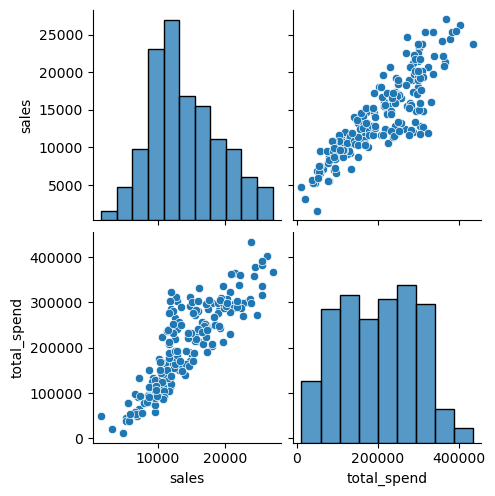

In [189]:
sns.pairplot(df)
plt.show()

In [190]:
df.corr()

,sales,total_spend
sales,1.000000,0.867712
total_spend,0.867712,1.000000


**Step 3.2: Data Cleaning**


In [191]:
df.isnull().sum()

sales          0
total_spend    0
dtype: int64

**3.3: Data Wangling**

In [192]:
#no encodding is required

**3.4: Train-Test Split**

In [193]:
X = df.drop(columns= 'sales')
y = df['sales']

from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=42)

## Step 4: Modelling
**y^​=b0​+b1​x**

**Modelling with default parameters**

In [194]:
#import
from sklearn.linear_model import LinearRegression

# save the model
model = LinearRegression()

#fit
model.fit(X_train, y_train)

# print intercept  (b0)
print(model.intercept_)

# print coef (b1)
print(model.coef_)







4199.106500868718
[0.04895385]


**Prediction**

In [195]:
train_Prediction = model.predict(X_train)
test_Prediction = model.predict(X_test)

## Step 5 : Evaluation

In [196]:
from sklearn.metrics import mean_absolute_error
print('MAE for test data: ', mean_absolute_error(y_test, test_Prediction))
print('MAE for traind data: ', mean_absolute_error(y_train, train_Prediction))

MAE for test data:  1914.3627368130553
MAE for traind data:  1963.9767578200754


In [197]:
from sklearn.metrics  import mean_squared_error
mse_test = mean_squared_error(y_test, test_Prediction)
mse_train  = mean_squared_error(y_train, train_Prediction)
print('MSE for test data: ',mse_test)
print('MSE for train data: ',mse_train)



MSE for test data:  6415866.312543218
MSE for train data:  6811655.464246887


In [198]:
print('RMSE for test data: ', np.sqrt(mse_test))
print('RMSE for train data: ', np.sqrt(mse_train))

RMSE for test data:  2532.9560423629973
RMSE for train data:  2609.9148385046756


In [199]:
from sklearn.metrics import r2_score
print('R2 for test data: ', r2_score(y_test, test_Prediction))
print('R2 for train data: ', r2_score(y_train, train_Prediction))


R2 for test data:  0.7650262463310722
R2 for train data:  0.7404192834391545


In [200]:
# Test R-Square
model.score(X_test, y_test)

0.7650262463310722

In [201]:
# Train R-score
model.score(X_train, y_train)

0.7404192834391545

### Checklist
**For any Supervised Machine learning Algorithm (Other than Linear Regression)**

- 1. Check whether model has overfitting or underfitting problem
- 2. Is Test Accuracy = Cross validation Score
- 4. Check model meets the business problem requiments 
- 5. Finally, save the model and share to the deployment team

**For linear Regression, in addition we have to**
- 3. Check Assumptions (if it is Linear Regression)

 1. Is model has underfitting or overfitting problem?
Answer : It's a good model.

 2. Is Test Accuracy -  Cross validation Score

In [202]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv = 5)
print(scores)
cv_score = scores.mean()
print('Cross validation Score: ', cv_score)

[0.74964192 0.79455226 0.76417134 0.74872042 0.65980565]
Cross validation Score:  0.7433783178555419


### Check for Assumption

1. Linear of Errors

In [205]:
test_res = y_test - test_Prediction


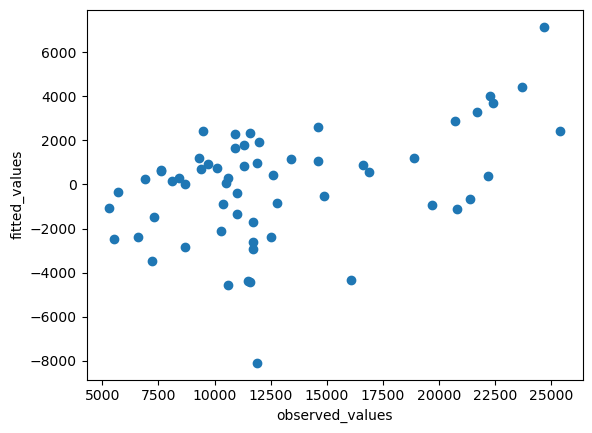

In [206]:
plt.scatter(y_test, test_res)
plt.xlabel('observed_values')
plt.ylabel('fitted_values')
plt.show()

2. Normality of Errors

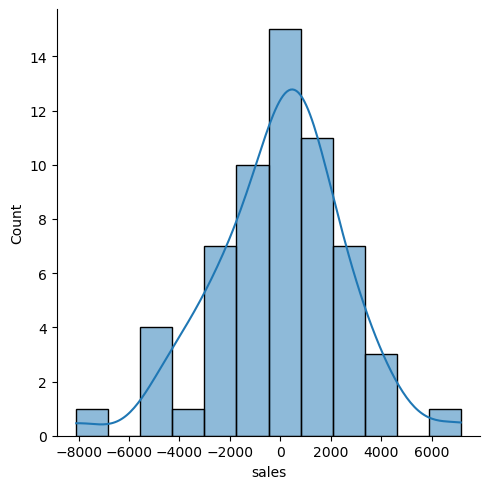

In [207]:
sns.displot(test_res, kde = True)
plt.show()

3. Equal variance of Errors (Homoscadesicity)

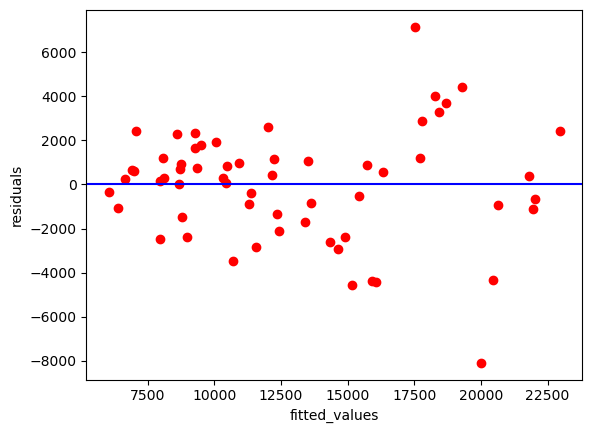

In [208]:
plt.scatter(test_Prediction, test_res, c = 'r')
plt.axhline(y = 0 , color = 'blue')
plt.xlabel('fitted_values')
plt.ylabel('residuals')
plt.show()

4. Variables Significance

In [209]:
import statsmodels.formula.api as smf
model2 = smf.ols('y~X', data = df).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     603.4
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           5.06e-62
Time:                        14:35:56   Log-Likelihood:                -1855.4
No. Observations:                 200   AIC:                             3715.
Df Residuals:                     198   BIC:                             3721.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4243.0282    438.525      9.676      0.000    3378.249    5107.807
X              0.0487      0.002     24.564      0.000       0.045       0.053
==============================================================================
Omnibus:                        6.851   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.033   Jarque-Bera (JB):                6.692
Skew:                          -0.373   Prob(JB):                       0.0352
Kurtosis:                       3.495   Cond. No.                     5.28e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.28e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Step 6 : Final Inferences

**Our next ad campaign will have a total spend of 200k on Ads, how many units colud we expect to sell as a result of this?**

In [211]:
# use the model to make predictions on a new value
model.predict([[321400]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([19932.87323262])

In [212]:
from joblib import dump
dump(model, 'sales_model.joblib')

['sales_model.joblib']

### Load a Model

In [213]:
from joblib import load
loaded_model = load('sales_model.joblib')

In [214]:
loaded_model.predict([[200000]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13989.87609126])